**Cohort Retention Analysis**

**VEDA Technology — Level 2, Day** **22**

In [2]:

from google.colab import files

uploaded = files.upload()

Saving veda_day22_cohort_retention_practice_data.csv to veda_day22_cohort_retention_practice_data.csv


In [3]:

import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (83, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,500011,21232,STRAWBERRY CERAMIC TRINKET BOX,5,2025-01-09 00:00:00,1.25,1003,United Kingdom
1,500014,22041,RECORD FRAME SINGLE SIZE,6,2025-01-10 00:00:00,2.10,1004,United Kingdom
2,500017,22138,BAKING SET RETROSPOT,7,2025-01-11 00:00:00,4.95,1005,United Kingdom
3,500001,84406B,CREAM CUPID HEARTS COAT HANGER,3,2025-01-12 00:00:00,2.75,1001,United Kingdom
4,500020,22613,PACK OF SPACEBOY NAPKINS,8,2025-01-12 00:00:00,0.85,1006,United Kingdom


In [4]:

# Step 2: Data Cleaning

# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Convert InvoiceDate into datetime format
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'], errors='coerce'
)

# Remove duplicate records
df = df.drop_duplicates()

# Remove rows without CustomerID or InvoiceDate
df = df.dropna(subset=['CustomerID', 'InvoiceDate'])

# Keep valid customer IDs
df = df[df['CustomerID'] > 0]

# Create invoice month column
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Display cleaned dataset
print("\nData cleaning completed!")
print("Cleaned dataset shape:", df.shape)
print("\nFirst 5 cleaned records:")

display(df.head())

Missing values before cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Data cleaning completed!
Cleaned dataset shape: (83, 9)

First 5 cleaned records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,500011,21232,STRAWBERRY CERAMIC TRINKET BOX,5,2025-01-09,1.25,1003,United Kingdom,2025-01
1,500014,22041,RECORD FRAME SINGLE SIZE,6,2025-01-10,2.10,1004,United Kingdom,2025-01
2,500017,22138,BAKING SET RETROSPOT,7,2025-01-11,4.95,1005,United Kingdom,2025-01
3,500001,84406B,CREAM CUPID HEARTS COAT HANGER,3,2025-01-12,2.75,1001,United Kingdom,2025-01
4,500020,22613,PACK OF SPACEBOY NAPKINS,8,2025-01-12,0.85,1006,United Kingdom,2025-01


In [5]:

print("Column data types:")
print(df.dtypes)

print("\nUnique customers:",
      df['CustomerID'].nunique())

print("\nUnique invoice months:",
      df['InvoiceMonth'].nunique())

print("\nDate range:")
print(df['InvoiceDate'].min(),
      "to",
      df['InvoiceDate'].max())

Column data types:
InvoiceNo                int64
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
UnitPrice              float64
CustomerID               int64
Country                 object
InvoiceMonth         period[M]
dtype: object

Unique customers: 30

Unique invoice months: 6

Date range:
2025-01-09 00:00:00 to 2025-06-22 00:00:00


In [6]:

# Step 3: Calculate Customer Cohort Month

# Find each customer's first purchase date
df['CohortMonth'] = (
    df.groupby('CustomerID')['InvoiceDate']
    .transform('min')
    .dt.to_period('M')
)

# Display customer-level cohort information
cohort_data = df[
    ['CustomerID', 'InvoiceDate', 'InvoiceMonth', 'CohortMonth']
].sort_values(['CustomerID', 'InvoiceDate'])

display(cohort_data.head(10))

,CustomerID,InvoiceDate,InvoiceMonth,CohortMonth
3,1001,2025-01-12,2025-01,2025-01
11,1001,2025-02-11,2025-02,2025-01
26,1001,2025-03-14,2025-03,2025-01
40,1001,2025-04-13,2025-04,2025-01
57,1001,2025-05-16,2025-05,2025-01
71,1001,2025-06-15,2025-06,2025-01
5,1002,2025-01-13,2025-01,2025-01
13,1002,2025-02-12,2025-02,2025-01
43,1002,2025-04-14,2025-04,2025-01
73,1002,2025-06-16,2025-06,2025-01


In [7]:

# One record per customer showing their cohort
customer_cohorts = (
    df.groupby('CustomerID')['CohortMonth']
    .first()
    .reset_index()
)

print("Total unique customers:",
      customer_cohorts['CustomerID'].nunique())

print("\nCustomers in each cohort month:")

print(
    customer_cohorts['CohortMonth']
    .value_counts()
    .sort_index()
)

display(customer_cohorts)

Total unique customers: 30

Customers in each cohort month:
CohortMonth
2025-01    8
2025-02    7
2025-03    5
2025-04    5
2025-05    3
2025-06    2
Freq: M, Name: count, dtype: int64


,CustomerID,CohortMonth
0,1001,2025-01
1,1002,2025-01
2,1003,2025-01
3,1004,2025-01
4,1005,2025-01
5,1006,2025-01
6,1007,2025-01
7,1008,2025-01
8,1009,2025-02
9,1010,2025-02


In [8]:

# Step 4: Calculate Cohort Index

# Convert cohort and invoice months into month numbers
df['CohortMonthNum'] = (
    df['CohortMonth'].dt.year * 12
    + df['CohortMonth'].dt.month
)

df['InvoiceMonthNum'] = (
    df['InvoiceMonth'].dt.year * 12
    + df['InvoiceMonth'].dt.month
)

# Calculate months since the customer's first purchase
df['CohortIndex'] = (
    df['InvoiceMonthNum'] - df['CohortMonthNum'] + 1
)

print("Cohort index calculated successfully!")
display(
    df[['CustomerID', 'InvoiceMonth',
        'CohortMonth', 'CohortIndex']].head(10)
)

Cohort index calculated successfully!


,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,1003,2025-01,2025-01,1
1,1004,2025-01,2025-01,1
2,1005,2025-01,2025-01,1
3,1001,2025-01,2025-01,1
4,1006,2025-01,2025-01,1
5,1002,2025-01,2025-01,1
6,1007,2025-01,2025-01,1
7,1008,2025-01,2025-01,1
8,1014,2025-02,2025-02,1
9,1015,2025-02,2025-02,1


In [9]:

# Count distinct active customers in each cohort month
cohort_counts = df.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID',
    aggfunc='nunique'
)

print("Cohort Customer Count Table:")
display(cohort_counts)

Cohort Customer Count Table:


CohortIndex,1,2,3,4,5,6
CohortMonth,,,,,,
2025-01,8.0,5.0,5.0,5.0,4.0,3.0
2025-02,7.0,4.0,4.0,4.0,3.0,NaN
2025-03,5.0,3.0,2.0,3.0,NaN,NaN
2025-04,5.0,3.0,3.0,NaN,NaN,NaN
2025-05,3.0,2.0,NaN,NaN,NaN,NaN
2025-06,2.0,NaN,NaN,NaN,NaN,NaN


In [10]:

# Calculate retention percentage
cohort_sizes = cohort_counts.iloc[:, 0]

retention_table = (
    cohort_counts
    .div(cohort_sizes, axis=0)
    * 100
)

retention_table = retention_table.round(2)

print("Cohort Retention Table (%):")
display(retention_table)

Cohort Retention Table (%):


CohortIndex,1,2,3,4,5,6
CohortMonth,,,,,,
2025-01,100.0,62.50,62.50,62.50,50.00,37.5
2025-02,100.0,57.14,57.14,57.14,42.86,NaN
2025-03,100.0,60.00,40.00,60.00,NaN,NaN
2025-04,100.0,60.00,60.00,NaN,NaN,NaN
2025-05,100.0,66.67,NaN,NaN,NaN,NaN
2025-06,100.0,NaN,NaN,NaN,NaN,NaN


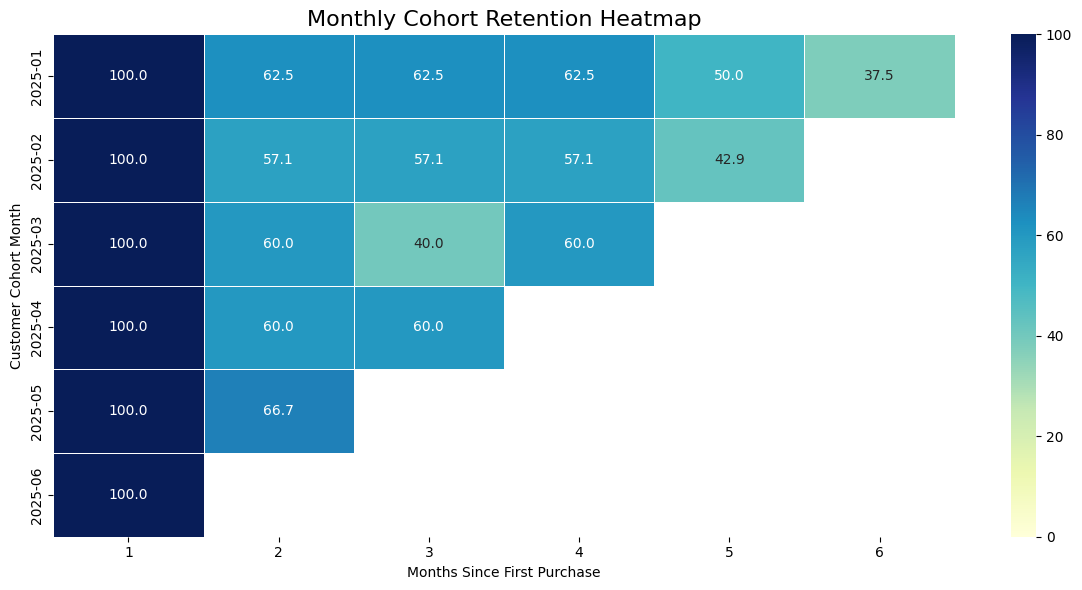

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

# Create a retention heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    retention_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    mask=retention_table.isna()
)

plt.title("Monthly Cohort Retention Heatmap", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort Month")

plt.tight_layout()
plt.show()

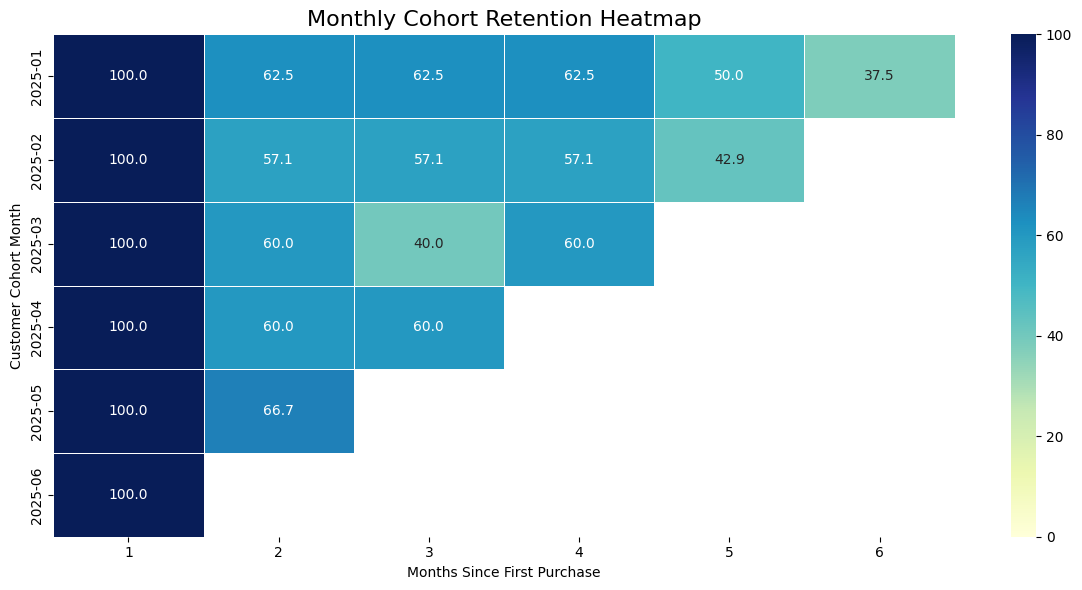

Heatmap saved successfully!


In [12]:

# Save heatmap as an image
plt.figure(figsize=(12, 6))

sns.heatmap(
    retention_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    mask=retention_table.isna()
)

plt.title("Monthly Cohort Retention Heatmap", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort Month")

plt.tight_layout()
plt.savefig(
    "cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Heatmap saved successfully!")

In [13]:

import sqlite3
import pandas as pd

# Prepare data for SQL
sql_df = df.copy()

sql_df['InvoiceMonth'] = sql_df['InvoiceMonth'].astype(str)
sql_df['CohortMonth'] = sql_df['CohortMonth'].astype(str)

# Create SQLite database
conn = sqlite3.connect('cohort_retention.db')

# Load cleaned data into SQL table
sql_df.to_sql(
    'transactions',
    conn,
    if_exists='replace',
    index=False
)

print("SQL database created successfully!")
print("Table name: transactions")

display(pd.read_sql_query(
    "SELECT * FROM transactions LIMIT 5",
    conn
))

SQL database created successfully!
Table name: transactions


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortMonthNum,InvoiceMonthNum,CohortIndex
0,500011,21232,STRAWBERRY CERAMIC TRINKET BOX,5,2025-01-09 00:00:00,1.25,1003,United Kingdom,2025-01,2025-01,24301,24301,1
1,500014,22041,RECORD FRAME SINGLE SIZE,6,2025-01-10 00:00:00,2.10,1004,United Kingdom,2025-01,2025-01,24301,24301,1
2,500017,22138,BAKING SET RETROSPOT,7,2025-01-11 00:00:00,4.95,1005,United Kingdom,2025-01,2025-01,24301,24301,1
3,500001,84406B,CREAM CUPID HEARTS COAT HANGER,3,2025-01-12 00:00:00,2.75,1001,United Kingdom,2025-01,2025-01,24301,24301,1
4,500020,22613,PACK OF SPACEBOY NAPKINS,8,2025-01-12 00:00:00,0.85,1006,United Kingdom,2025-01,2025-01,24301,24301,1


In [14]:

query1 = """
SELECT
    CohortMonth,
    COUNT(DISTINCT CustomerID) AS New_Customers
FROM transactions
GROUP BY CohortMonth
ORDER BY CohortMonth;
"""

result1 = pd.read_sql_query(query1, conn)

print("QUERY 1: Cohort-wise New Customers")
display(result1)

QUERY 1: Cohort-wise New Customers


,CohortMonth,New_Customers
0,2025-01,8
1,2025-02,7
2,2025-03,5
3,2025-04,5
4,2025-05,3
5,2025-06,2


In [15]:

query2 = """
SELECT
    InvoiceMonth,
    COUNT(DISTINCT CustomerID) AS Active_Customers
FROM transactions
GROUP BY InvoiceMonth
ORDER BY InvoiceMonth;
"""

result2 = pd.read_sql_query(query2, conn)

print("QUERY 2: Monthly Active Customers")
display(result2)

QUERY 2: Monthly Active Customers


,InvoiceMonth,Active_Customers
0,2025-01,8
1,2025-02,12
2,2025-03,14
3,2025-04,17
4,2025-05,16
5,2025-06,16


In [16]:

query3 = """
WITH monthly_activity AS (
    SELECT
        CohortMonth,
        InvoiceMonth,
        (
            CAST(SUBSTR(InvoiceMonth, 1, 4) AS INTEGER) * 12
            + CAST(SUBSTR(InvoiceMonth, 6, 2) AS INTEGER)
            - CAST(SUBSTR(CohortMonth, 1, 4) AS INTEGER) * 12
            - CAST(SUBSTR(CohortMonth, 6, 2) AS INTEGER)
            + 1
        ) AS CohortIndex,
        COUNT(DISTINCT CustomerID) AS Active_Customers
    FROM transactions
    GROUP BY CohortMonth, InvoiceMonth
),
cohort_sizes AS (
    SELECT
        CohortMonth,
        COUNT(DISTINCT CustomerID) AS Cohort_Size
    FROM transactions
    GROUP BY CohortMonth
)
SELECT
    m.CohortMonth,
    m.CohortIndex,
    m.Active_Customers,
    c.Cohort_Size,
    ROUND(
        100.0 * m.Active_Customers / c.Cohort_Size,
        2
    ) AS Retention_Percentage
FROM monthly_activity m
JOIN cohort_sizes c
    ON m.CohortMonth = c.CohortMonth
ORDER BY m.CohortMonth, m.CohortIndex;
"""

result3 = pd.read_sql_query(query3, conn)

print("QUERY 3: Cohort Retention Percentages")
display(result3)

QUERY 3: Cohort Retention Percentages


,CohortMonth,CohortIndex,Active_Customers,Cohort_Size,Retention_Percentage
0,2025-01,1,8,8,100.00
1,2025-01,2,5,8,62.50
2,2025-01,3,5,8,62.50
3,2025-01,4,5,8,62.50
4,2025-01,5,4,8,50.00
5,2025-01,6,3,8,37.50
6,2025-02,1,7,7,100.00
7,2025-02,2,4,7,57.14
8,2025-02,3,4,7,57.14
9,2025-02,4,4,7,57.14


In [17]:

result1.to_csv('sql_query1_cohort_sizes.csv', index=False)
result2.to_csv('sql_query2_monthly_active_customers.csv', index=False)
result3.to_csv('sql_query3_retention_percentages.csv', index=False)

print("All 3 SQL query outputs saved successfully!")

All 3 SQL query outputs saved successfully!


In [18]:

# Step 7: Business Insights

print("=" * 60)
print("COHORT RETENTION ANALYSIS - BUSINESS INSIGHTS")
print("=" * 60)

# 1. Customer acquisition by cohort
print("\n1. CUSTOMER ACQUISITION")
print("Customers acquired in each cohort month:")
display(cohort_sizes.rename("New_Customers").to_frame())

largest_cohort = cohort_sizes.idxmax()
smallest_cohort = cohort_sizes.idxmin()

print(f"Largest cohort: {largest_cohort} "
      f"({cohort_sizes.max()} customers)")
print(f"Smallest cohort: {smallest_cohort} "
      f"({cohort_sizes.min()} customers)")

# 2. Month 2 retention for cohorts with available data
if 2 in retention_table.columns:
    month2 = retention_table[2].dropna()

    if not month2.empty:
        print("\n2. MONTH 2 RETENTION")
        display(month2.rename("Retention_Percentage").to_frame())

        best_month2 = month2.idxmax()
        print(f"Highest Month 2 retention: {best_month2} "
              f"({month2.max():.2f}%)")

# 3. Overall retention pattern
print("\n3. RETENTION PATTERN")
average_retention = retention_table.mean(axis=0).round(2)
display(average_retention.rename(
    "Average_Cohort_Retention_Percentage"
).to_frame())

# 4. Business recommendations
print("\n4. BUSINESS RECOMMENDATIONS")
print("- Study repeat-purchase behavior of retained customers.")
print("- Use targeted campaigns to encourage second purchases.")
print("- Compare cohorts over the same number of months.")
print("- Investigate product preferences and purchase frequency.")

print("\nAnalysis completed.")

COHORT RETENTION ANALYSIS - BUSINESS INSIGHTS

1. CUSTOMER ACQUISITION
Customers acquired in each cohort month:


,New_Customers
CohortMonth,
2025-01,8.0
2025-02,7.0
2025-03,5.0
2025-04,5.0
2025-05,3.0
2025-06,2.0


Largest cohort: 2025-01 (8.0 customers)
Smallest cohort: 2025-06 (2.0 customers)

2. MONTH 2 RETENTION


,Retention_Percentage
CohortMonth,
2025-01,62.50
2025-02,57.14
2025-03,60.00
2025-04,60.00
2025-05,66.67


Highest Month 2 retention: 2025-05 (66.67%)

3. RETENTION PATTERN


,Average_Cohort_Retention_Percentage
CohortIndex,
1,100.00
2,61.26
3,54.91
4,59.88
5,46.43
6,37.50



4. BUSINESS RECOMMENDATIONS
- Study repeat-purchase behavior of retained customers.
- Use targeted campaigns to encourage second purchases.
- Compare cohorts over the same number of months.
- Investigate product preferences and purchase frequency.

Analysis completed.


In [19]:

# VEDA Day 22 - Final Validation

print("=" * 55)
print("VEDA TECHNOLOGY | LEVEL 2 - DAY 22")
print("COHORT RETENTION ANALYSIS")
print("=" * 55)

print("\n1. DATASET")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique customers:", df['CustomerID'].nunique())

print("\n2. COHORT TABLE")
display(cohort_counts)

print("\n3. RETENTION TABLE (%)")
display(retention_table)

print("\n4. SQL QUERY OUTPUTS")
print("Query 1 - Cohort sizes:", result1.shape)
print("Query 2 - Monthly active customers:", result2.shape)
print("Query 3 - Retention percentages:", result3.shape)

print("\n5. FINAL CHECKS")
print("Missing CustomerIDs:", df['CustomerID'].isna().sum())
print("Missing InvoiceDates:", df['InvoiceDate'].isna().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nValidation cell executed.")

VEDA TECHNOLOGY | LEVEL 2 - DAY 22
COHORT RETENTION ANALYSIS

1. DATASET
Rows: 83
Columns: 13
Unique customers: 30

2. COHORT TABLE


CohortIndex,1,2,3,4,5,6
CohortMonth,,,,,,
2025-01,8.0,5.0,5.0,5.0,4.0,3.0
2025-02,7.0,4.0,4.0,4.0,3.0,NaN
2025-03,5.0,3.0,2.0,3.0,NaN,NaN
2025-04,5.0,3.0,3.0,NaN,NaN,NaN
2025-05,3.0,2.0,NaN,NaN,NaN,NaN
2025-06,2.0,NaN,NaN,NaN,NaN,NaN



3. RETENTION TABLE (%)


CohortIndex,1,2,3,4,5,6
CohortMonth,,,,,,
2025-01,100.0,62.50,62.50,62.50,50.00,37.5
2025-02,100.0,57.14,57.14,57.14,42.86,NaN
2025-03,100.0,60.00,40.00,60.00,NaN,NaN
2025-04,100.0,60.00,60.00,NaN,NaN,NaN
2025-05,100.0,66.67,NaN,NaN,NaN,NaN
2025-06,100.0,NaN,NaN,NaN,NaN,NaN



4. SQL QUERY OUTPUTS
Query 1 - Cohort sizes: (6, 2)
Query 2 - Monthly active customers: (6, 2)
Query 3 - Retention percentages: (21, 5)

5. FINAL CHECKS
Missing CustomerIDs: 0
Missing InvoiceDates: 0
Duplicate rows: 0

Validation cell executed.
